In [96]:
import os
import sys
import pickle
import numpy as np

sys.path.append(os.path.abspath("../../"))
import matplotlib as mpl
import matplotlib.pyplot as plt
import scienceplots
import string
import importlib


def reload_utils():
    importlib.reload(scienceplots)
    plt.style.use("science")
    plt.rcParams["font.sans-serif"] = ["Arial"]
    plt.rcParams["font.family"] = "sans-serif"
    mpl.rcParams.update(
        {
            "text.usetex": True,
            "text.latex.preamble": r"""
            \usepackage[scaled]{helvet}    % Nimbus Sans L ≈ Arial
            \usepackage[EULERGREEK]{sansmath}  % math in sans serif
            \usepackage{bm}
            \usepackage{amsmath}
            \usepackage{amsfonts}
            \DeclareMathSymbol{\shortminus}{\mathbin}{AMSa}{"39}
            \sansmath
            \renewcommand{\familydefault}{\sfdefault}   % default to sans
        """,
        }
    )
    np.set_printoptions(suppress=True)
    return None


reload_utils()

mol_map = {
    "cyclotrisiloxane": "mol1",
    "silanol_trimethyl": "mol2",
    "trisiloxane": "mol3",
}

paper_names = {
    "trisiloxane": "TSH",
    "cyclotrisiloxane": "CTS",
    "silanol_trimethyl": "ST",
}

mol_colors = {
    "cyclotrisiloxane": "black",
    "silanol_trimethyl": "goldenrod",
    "trisiloxane": "darkred",
}
mol_markers = {"cyclotrisiloxane": "o", "silanol_trimethyl": "s", "trisiloxane": "^"}
alphabet = string.ascii_lowercase
figure_path = "/home/gtdebru/phase/figures/lvc/"

In [97]:
mols = list(mol_map.keys())
domes = []
vps = []
for mol in mols:
    results_dir = f"/home/gtdebru/{mol}/lvc/results/"
    dome_file = f"{results_dir}vapor_dome_{paper_names[mol]}.pkl"
    vp_file = f"{results_dir}vapor_pressure_{paper_names[mol]}.pkl"
    with open(dome_file, "rb") as file:
        dome = pickle.load(file)
        dome["mol"] = mol
        domes.append(dome)

    with open(vp_file, "rb") as file:
        vp = pickle.load(file)
        vp["mol"] = mol
        vps.append(vp)

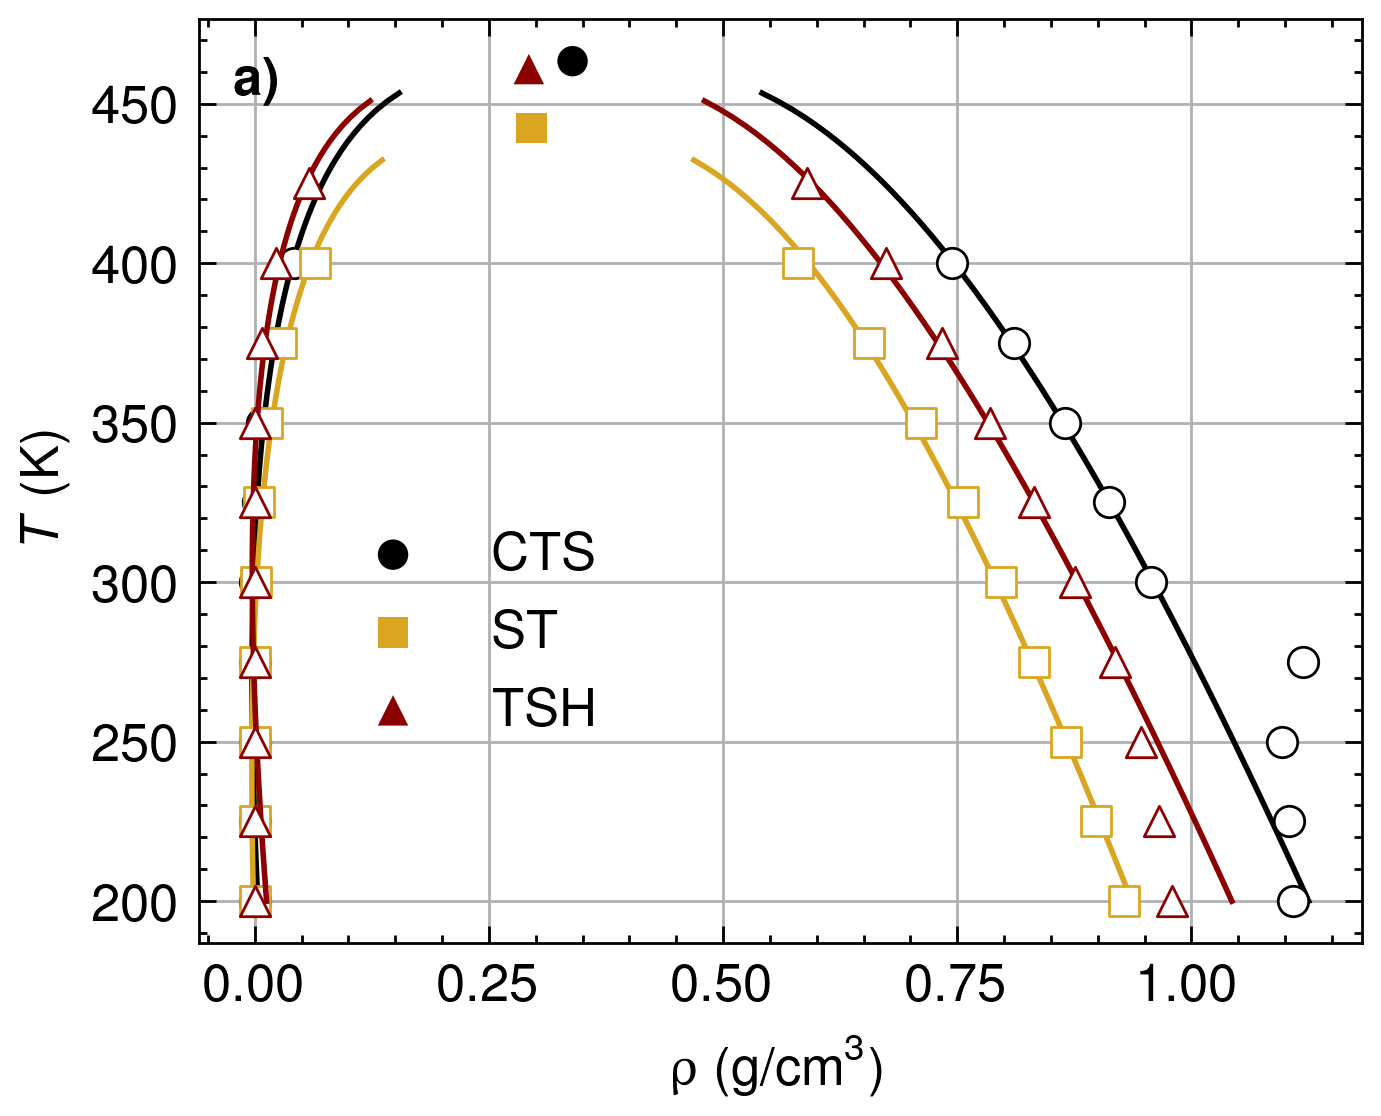

In [104]:
def plot_vapor_domes(domes, ax=None):

    global paper_names
    global mol_colors
    global mol_markers
    if ax is None:

        fig, ax = plt.subplots(dpi=400, figsize=(7.5 / 2, 3))

    else:
        fig = ax.figure

    s = 30
    lw = 0.7

    for i, dome in enumerate(domes):

        Tc = dome["Tc"]
        rhoc = dome["rhoc"]
        T_fit = dome["T_fit"]
        temps = dome["T"]
        rho_l_fit = dome["rho_l_fit"]
        rho_g_fit = dome["rho_g_fit"]
        rho_ls = dome["rho_l"]
        rho_gs = dome["rho_g"]
        mol = dome["mol"]
        paper_name = paper_names[mol]

        ax.plot(rho_l_fit, T_fit, color=mol_colors[mol])
        ax.plot(rho_g_fit, T_fit, color=mol_colors[mol])

        ax.scatter(
            rhoc,
            Tc,
            marker=mol_markers[mol],
            color=mol_colors[mol],
            s=s,
            zorder=10,
            label=paper_name,
            edgecolors="none",
        )

        ax.scatter(
            rho_ls,
            temps,
            color=mol_colors[mol],
            marker=mol_markers[mol],
            s=s,
            zorder=2,
            facecolors="white",
            linewidths=0.5,
        )
        ax.scatter(
            rho_gs,
            temps,
            color=mol_colors[mol],
            marker=mol_markers[mol],
            s=s,
            zorder=2,
            facecolors="white",
            linewidths=0.5,
        )

    ax.set_xlabel(r"$\rho \ (\text{g/cm}^{3}) $")
    ax.set_ylabel(r"$T \ (\text{K})$")
    ax.text(
        0.03,
        0.96,
        rf"$\textbf{{{alphabet[0]})}}$",
        transform=ax.transAxes,
        fontsize=10,
        weight="bold",
        va="top",
        ha="left",
    )
    ax.grid()
    ax.legend(loc=(0.1, 0.2))

    return fig, ax


fig, ax = plot_vapor_domes(domes)
fig.savefig(figure_path + "mol_domes.png", dpi=400)
plt.show()

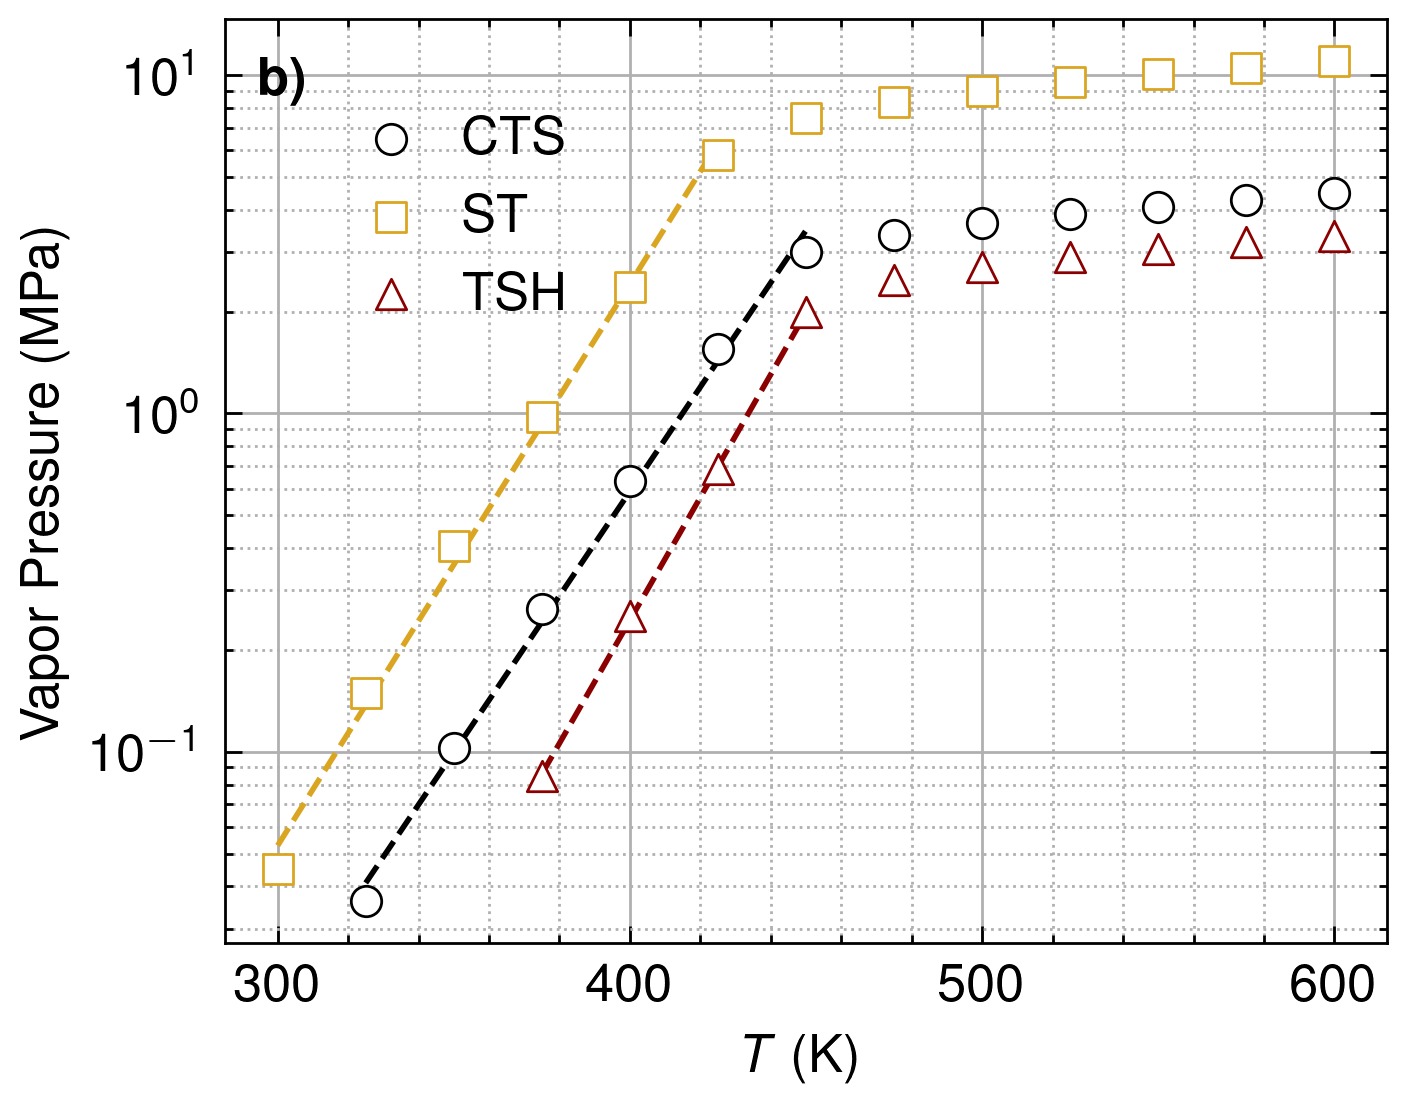

In [105]:
def plot_vapor_pressures(vps, ax=None):

    global paper_names
    global mol_colors
    global mol_markers

    if ax is None:

        fig, ax = plt.subplots(dpi=400, figsize=(7.5 / 2, 3))

    else:
        fig = ax.figure

    s = 30
    fit_ends = {"CTS": 450, "ST": 425, "TSH": 450}

    for i, vp in enumerate(vps):

        T = vp["T"]
        mol = vp["mol"]
        paper_name = paper_names[mol]
        P = vp["P"]
        ax.scatter(
            T,
            P,
            label=paper_name,
            color=mol_colors[mol],
            marker=mol_markers[mol],
            zorder=10,
            facecolors="white",
            linewidths=0.5,
            s=s,
        )

        fit_end = np.where(T == fit_ends[paper_name])[0][0] + 1
        m, b = np.polyfit(T[:fit_end], np.log10(P[:fit_end]), deg=1)
        x = np.linspace(T.min(), T[fit_end - 1], 100)

        y = m * x + b
        y = 10**y
        ax.plot(x, y, color=mol_colors[mol], linestyle="--")

    ax.text(
        0.03,
        0.96,
        rf"$\textbf{{{alphabet[1]})}}$",
        transform=ax.transAxes,
        fontsize=10,
        weight="bold",
        va="top",
        ha="left",
    )

    ax.set_yscale("log")
    ax.grid()
    ax.grid(which="major", linestyle="-")
    ax.grid(which="minor", linestyle=":")
    ax.legend(handlelength=1, loc=(0.1, 0.65))

    ax.set_xlabel(r"$T \ (\text{K})$")
    ax.set_ylabel("Vapor Pressure (MPa)")

    return fig, ax


fig, ax = plot_vapor_pressures(vps)
fig.savefig(figure_path + "mol_pressures.png", dpi=400)
plt.show()

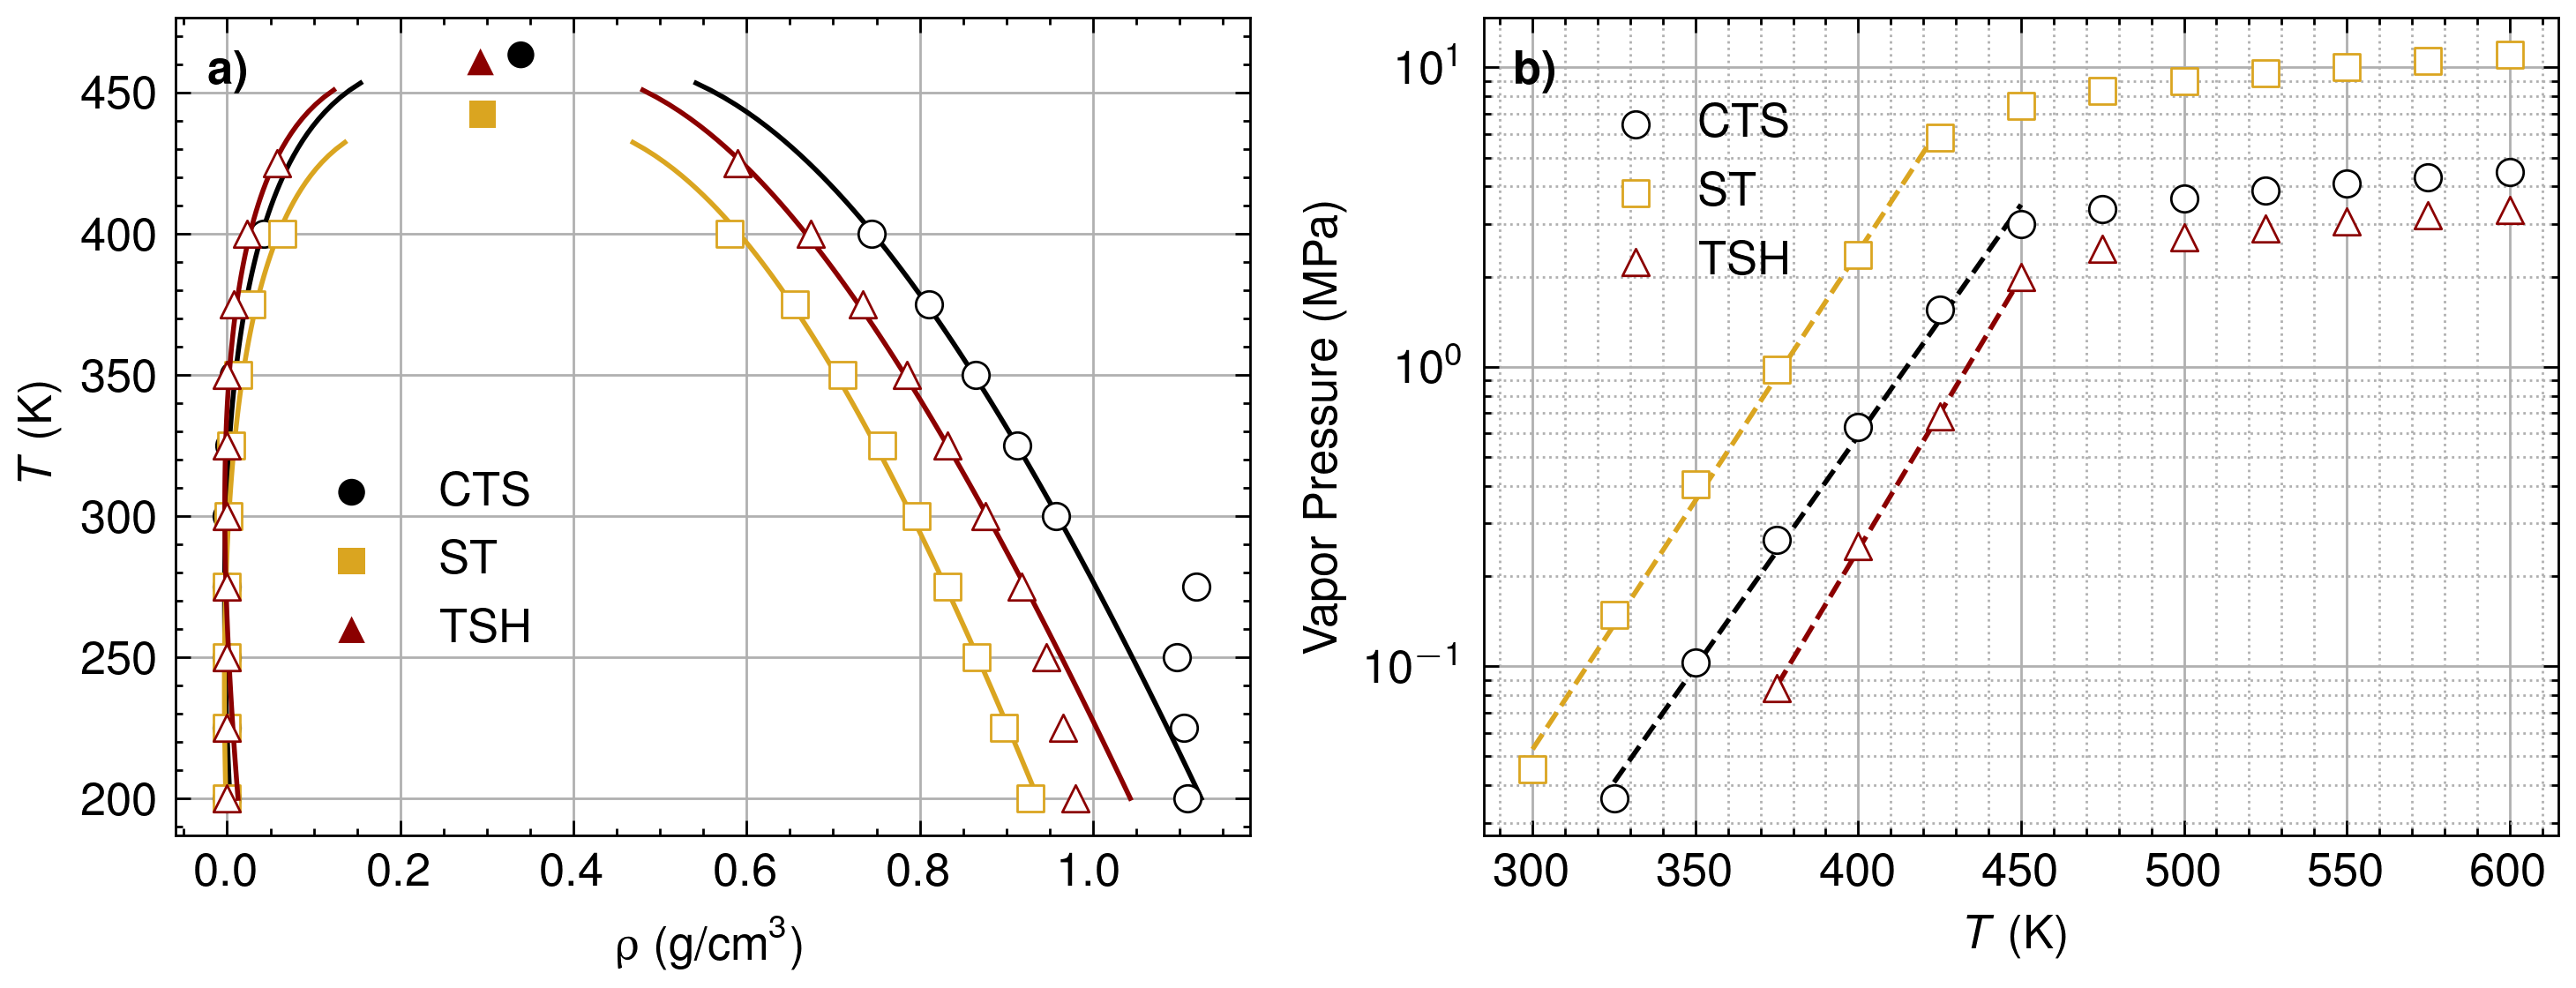

In [106]:
fig, axs = plt.subplots(dpi=400, figsize=(7.5, 3), ncols=2)

_ = plot_vapor_domes(domes, axs[0])
_ = plot_vapor_pressures(vps, axs[1])
fig.tight_layout()
fig.savefig(figure_path + "mol_domes_pressures.png", dpi=400)
plt.show()

In [107]:
os.listdir(figure_path)

['mol_pressures.png', 'mol_domes_pressures.png', 'mol_domes.png']